# GSE125527 初步分析
直肠回肠组织 免疫细胞 样本，21个样本  
7UC，14HC
- UC20-UC26
- HC17-HC30

# 文件说明
- **文件名**: 6_GSE125527_tissue.h5ad  
- **存放位置**: 坚果云  `UC/scRNA-seq_data/data_qc/`  
- **生成日期**: 2025-10-23  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/6_GSE125527_tissue_preprocessing.ipynb  
- **内容说明**: 包含质控和去除双细胞后的数据集数据，保存为h5ad文件，方便后续合并时读取  

In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


In [2]:
!pwd

/home/future/UC_Treg_Project/notebooks/1_preprocessing


## 读取表达矩阵类型数据

In [5]:
import pandas as pd
import os

data_dir = "/mnt/e/UC/scRNA-seq_RAW/6_GSE125527/tissue"
adatas = []

for file in sorted(os.listdir(data_dir)):
    if not (file.endswith(".tsv") or file.endswith(".csv") or file.endswith(".txt")):
        continue

    path = os.path.join(data_dir, file)
    sample = os.path.splitext(file)[0]

    # 自动识别分隔符
    sep = "\t" if file.endswith((".tsv", ".txt")) else ","
    df = pd.read_csv(path, sep=sep, index_col=0)

    ad = sc.AnnData(df) # 针对这个表达矩阵不转置
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)

    ad.obs['GSM_id'] = sample
    ad.obs_names = [f"{sample}_{x}" for x in ad.obs_names]
    adatas.append(ad)

adata = sc.concat(adatas, merge='same')

filtered out 258 genes that are detected in less than 3 cells
filtered out 56 genes that are detected in less than 3 cells
filtered out 35 genes that are detected in less than 3 cells
filtered out 43 genes that are detected in less than 3 cells
filtered out 44 genes that are detected in less than 3 cells
filtered out 7 genes that are detected in less than 3 cells
filtered out 18 genes that are detected in less than 3 cells
filtered out 28 genes that are detected in less than 3 cells
filtered out 64 genes that are detected in less than 3 cells
filtered out 34 genes that are detected in less than 3 cells
filtered out 59 genes that are detected in less than 3 cells
filtered out 56 genes that are detected in less than 3 cells
filtered out 50 genes that are detected in less than 3 cells
filtered out 63 genes that are detected in less than 3 cells
filtered out 135 genes that are detected in less than 3 cells
filtered out 154 genes that are detected in less than 3 cells
filtered out 90 genes 

In [6]:
adata

AnnData object with n_obs × n_vars = 43267 × 9713
    obs: 'n_genes', 'GSM_id'

In [7]:
adata.obs['GSM_id'].value_counts()

GSM_id
GSM3576401_UC22    3052
GSM3576404_UC25    3039
GSM3576428_HC27    3036
GSM3576402_UC23    2786
GSM3576430_HC29    2666
GSM3576429_HC28    2600
GSM3576408_HC22    2580
GSM3576399_UC20    2577
GSM3576400_UC21    2417
GSM3576398_HC19    2412
GSM3576405_UC26    2402
GSM3576403_UC24    2369
GSM3576409_HC23    2189
GSM3576410_HC24    2074
GSM3576397_HC18    1911
GSM3576427_HC26    1132
GSM3576431_HC30    1062
GSM3576406_HC20    1028
GSM3576407_HC21     997
GSM3576426_HC25     617
GSM3576396_HC17     321
Name: count, dtype: int64

In [8]:
adata.obs['GSM'] = adata.obs['GSM_id'].str.split("_").str[0]  
adata.obs['id']  = adata.obs['GSM_id'].str.split("_").str[1]  

## 预处理步骤
- QC: mito<0.2, UMI>500, genes>250, 去除双细胞
- HVG: Pearson方法，2000个
- PCA: 50个PCs
- neighbors: 最邻近数15，使用前50PCs
- leiden: resolution0.5

In [9]:
# QC
adata=ov.pp.qc(adata,
               tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
               doublets_method='scrublet',
               batch_key=None)

adata

⚙️ Using CPU/GPU mixed mode for QC...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    |||||------------------------- 2777/16311 MiB (17.0%)

🔍 Quality Control Analysis (CPU-GPU Mixed):
   Dataset shape: 43,267 cells × 9,713 genes
   QC mode: seurat
   Doublet detection: scrublet
   Mitochondrial genes: MT-

📊 Step 1: Calculating QC Metrics
   Mitochondrial genes (prefix 'MT-'): 0 found
   ✓ QC metrics calculated:
     • Mean nUMIs: 2718 (range: 539-29330)
     • Mean genes: 858 (range: 380-5832)
     • Mean mitochondrial %: 0.0% (max: 0.2%)

🔧 Step 2: Quality Filtering (SEURAT)
   Thresholds: mito≤0.2, nUMIs≥500, genes≥250
   📊 Seurat Filter Results:
     • nUMIs filter (≥500): 0 cells failed (0.0%)
     • Genes filter (≥250): 0 cells failed (0.0%)
     • Mitochondrial filter (≤0.2): 0 cells failed (0.0%)
   ✓ Combined QC filters: 0 cells removed (0.0%)

🎯 Step 3: Final Filtering
   Parameters: min_genes=200, min_cells=3
   Ratios: max_genes_ratio=1, max_cells_rati

AnnData object with n_obs × n_vars = 43267 × 9713
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'n_cells'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU'

## 保存质控后数据（去除双细胞）


In [10]:
output_dir = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/data_qc/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "6_GSE125527_tissue.h5ad"), compression='gzip')

In [11]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.5)

Begin robust gene identification
After filtration, 9713/9713 genes are kept.     Among 9713 genes, 9713 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
['IGKC', 'IGKV4.1', 'IGKV1.5', 'IGKV1.9', 'IGKV3.11', 'IGKV3.15', 'IGKV1.17', 'IGKV3.20', 'IGKV2.30', 'JCHAIN', 'MALAT1', 'IGHA2', 'IGHA1', 'IGHG1', 'IGHM', 'IGHV1.2', 'IGHV1.3', 'IGHV4.4', 'IGHV2.5', 'IGHV3.7', 'IGHV3.11', 'IGHV3.15', 'IGHV1.18', 'IGHV3.21', 'IGHV3.23', 'IGHV3.30', 'IGHV4.31', 'IGHV3.33', 'IGHV4.34', 'IGHV4.39', 'IGHV1.46', 'IGHV5.51', 'IGHV4.59', 'IGHV3.74', 'IGLV1.51', 'IGLV1.47', 'IGLV1.44', 'IGLV1.40', 'IGLV3.25', 'IGLV2.23', 'IGLV3.21', 'IGLV3.19', 'IGLV2.14', 'IGLV2.11', 'IGLV2.8', 'IGLV3.1']
    finished (0:00:02)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variab

In [12]:
adata

AnnData object with n_obs × n_vars = 43267 × 2000
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'mt', 'n_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'scaled|original|X_pca', 'X_umap'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

指控后每个样本细胞数

In [13]:
adata.obs['id'].value_counts()

id
UC22    3052
UC25    3039
HC27    3036
UC23    2786
HC29    2666
HC28    2600
HC22    2580
UC20    2577
UC21    2417
HC19    2412
UC26    2402
UC24    2369
HC23    2189
HC24    2074
HC18    1911
HC26    1132
HC30    1062
HC20    1028
HC21     997
HC25     617
HC17     321
Name: count, dtype: int64

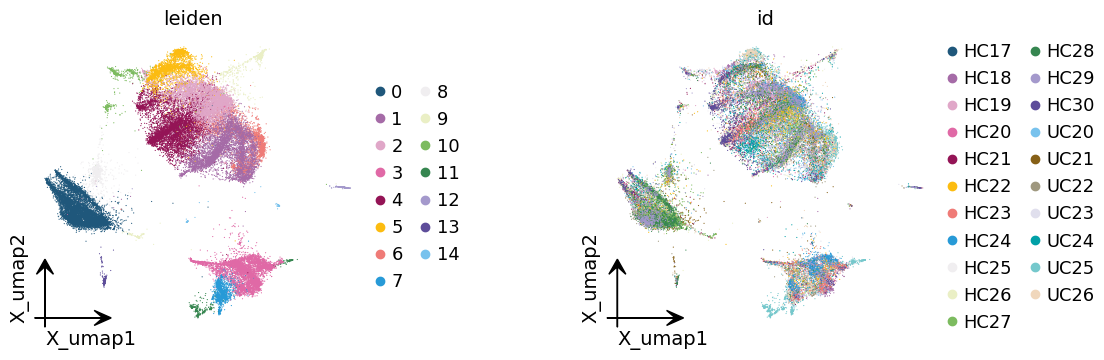

In [14]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'id'],
                frameon='small',
                wspace=0.5)

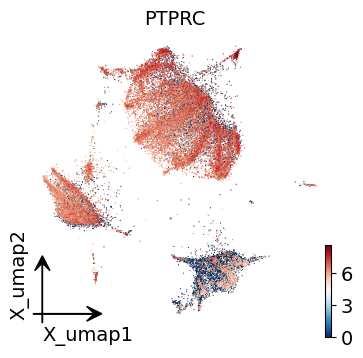

In [15]:
# 粗略查看免疫基因
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC'],
                frameon='small')

## GPT自动注释

In [16]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:23)


{'0': ['CD83',
  'HLA.DQB1',
  'HLA.DQA1',
  'CD37',
  'HLA.DRB1',
  'HLA.DPA1',
  'HLA.DPB1',
  'CD74',
  'MS4A1',
  'HLA.DRA'],
 '1': ['LDHB',
  'CD7',
  'RGCC',
  'SPOCK2',
  'LAT',
  'FYB1',
  'IFITM1',
  'LTB',
  'CD3E',
  'CD3D'],
 '10': ['CD7',
  'TRDC',
  'GNLY',
  'KLRD1',
  'CTSW',
  'TYROBP',
  'FCER1G',
  'NFKBIA',
  'IFITM2',
  'NKG7'],
 '11': ['SSR4',
  'XBP1',
  'MZB1',
  'IGLV1.40',
  'UBC',
  'IGHG1',
  'HSP90B1',
  'DERL3',
  'PRDX4',
  'CYBA'],
 '12': ['FTH1',
  'CST3',
  'HLA.DRB5',
  'HLA.DRB1',
  'TYROBP',
  'HLA.DPA1',
  'FCER1G',
  'HLA.DPB1',
  'AIF1',
  'HLA.DRA'],
 '13': ['GAPDH',
  'SERF2',
  'ACTG1',
  'LRMP',
  'CD79B',
  'MARCKSL1',
  'HMGB1',
  'MS4A1',
  'HMGN2',
  'H3F3A'],
 '14': ['TSC22D1',
  'CST3',
  'LMNA',
  'CD63',
  'LAPTM4A',
  'S100A11',
  'CD9',
  'LGALS3',
  'S100A6',
  'VIM'],
 '2': ['S100A4',
  'IL7R',
  'ANXA1',
  'CCL5',
  'CD96',
  'KLRB1',
  'TNFAIP3',
  'ID2',
  'IL32',
  'CD3E'],
 '3': ['SSR4',
  'JCHAIN',
  'MZB1',
  'IGHA1',
  'SE

In [18]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='Immune cell',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'Dendritic cells',
 '1': 'T cells',
 '10': 'NK cells and T cells',
 '11': 'Plasma cells',
 '12': 'Monocytes and dendritic cells',
 '13': 'B cells',
 '14': 'Macrophages and dendritic cells',
 '2': 'T cells and NK cells',
 '3': 'Plasma cells',
 '4': 'T cells and NK cells',
 '5': 'Cytotoxic T cells and NK cells',
 '6': 'T cells',
 '7': 'Plasma cells',
 '8': 'Dendritic cells',
 '9': 'Mixed immune cell types'}

In [ ]:
#os.environ['AGI_API_KEY'] = 'sk-p0VgGvztXDK2erOoUul7cHcSDt4UduGk6f8voA0zn1F1L5xe'
#result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='moonshot-v1-8k',
                               provider='kimi',
                               topgenenumber=10)
#result

In [19]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

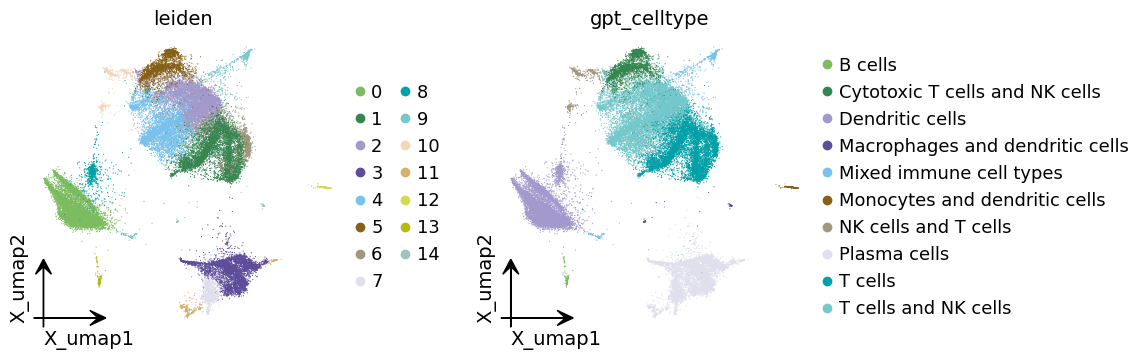

In [20]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [21]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
T cells and NK cells               27.388079
Dendritic cells                    21.762544
T cells                            19.462870
Plasma cells                       18.982134
Cytotoxic T cells and NK cells      6.235699
Mixed immune cell types             1.934500
NK cells and T cells                1.879030
Monocytes and dendritic cells       1.356692
B cells                             0.718793
Macrophages and dendritic cells     0.279659
Name: proportion, dtype: float64
